**Automatic Detection and Quantification of Defective Corn Kernels Using YOLOv8 and Multi-Object Tracking**

Este bloco é um pipeline cientifico voltado para (a) Detecção de grãos defeituosos; (b) Classificação dos defeitos; (c) Rastreamento com ByteTrack;
Contagem sem duplicidade; (d) Geração automática de estatísticas do lote.

**Parte 1 – Download do Dataset de Milho**

In [5]:
!nvidia-smi

Tue Jul 14 01:47:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
#1. Instalação do Yolov8
!pip install ultralytics==8.4.90

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.0/112.6 GB disk)


In [7]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [8]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="TSzCvpzsORH4ZZNlhbMq")
project = rf.workspace("celsio-assane").project("corn-lycsy-gfkgc")
version = project.version(4)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [9]:

from ultralytics import YOLO

# Carregar modelo pré-treinado
model = YOLO("yolov8s.pt")

# Treinamento
model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=300,
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)

New https://pypi.org/project/ultralytics/8.4.95 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/corn-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ac4ddc0d850>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [10]:
metrics = model.val()

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1372.7±389.7 MB/s, size: 32.7 KB)
val: Scanning /content/corn-4/valid/labels.cache... 111 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 111/111 33.3Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1380, len(boxes) = 7393. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.1s/it 14.5s
                   all        111       7393      0.906      0.917      0.941      0.714
                   Bad         51       1549       0.85      0.864      0.893      0.637
               Damaged         92       28

In [11]:
P = metrics.box.mp
R = metrics.box.mr

F1 = 2 * P * R / (P + R)

print(f"Precision : {P:.4f}")
print(f"Recall    : {R:.4f}")
print(f"F1-score  : {F1:.4f}")

Precision : 0.9062
Recall    : 0.9166
F1-score  : 0.9114


In [12]:
import pandas as pd

# Métricas por classe
P = metrics.box.p
R = metrics.box.r
F1 = 2 * P * R / (P + R)

mAP50 = metrics.box.ap50
mAP5095 = metrics.box.ap

# Nome das classes
classes = ["Bad", "Damaged", "Good"]

# Criar DataFrame
df = pd.DataFrame({
    "Class": classes,
    "Precision": P,
    "Recall": R,
    "F1-score": F1,
    "mAP@0.50": mAP50,
    "mAP@0.50:0.95": mAP5095
})

print(df.round(3))

     Class  Precision  Recall  F1-score  mAP@0.50  mAP@0.50:0.95
0      Bad      0.850   0.864     0.857     0.893          0.637
1  Damaged      0.950   0.923     0.936     0.967          0.757
2     Good      0.919   0.963     0.940     0.965          0.747


In [13]:
!ls -R /content/runs/detect

/content/runs/detect:
train  val

/content/runs/detect/train:
args.yaml			 labels.jpg		val_batch0_pred.jpg
BoxF1_curve.png			 results.csv		val_batch1_labels.jpg
BoxP_curve.png			 results.png		val_batch1_pred.jpg
BoxPR_curve.png			 train_batch0.jpg	val_batch2_labels.jpg
BoxR_curve.png			 train_batch1.jpg	val_batch2_pred.jpg
confusion_matrix_normalized.png  train_batch2.jpg	weights
confusion_matrix.png		 val_batch0_labels.jpg

/content/runs/detect/train/weights:
best.pt  last.pt

/content/runs/detect/val:
BoxF1_curve.png  confusion_matrix_normalized.png  val_batch1_labels.jpg
BoxP_curve.png	 confusion_matrix.png		  val_batch1_pred.jpg
BoxPR_curve.png  val_batch0_labels.jpg		  val_batch2_labels.jpg
BoxR_curve.png	 val_batch0_pred.jpg		  val_batch2_pred.jpg


In [ ]:
!find /content -type d -name "test"

/content/corn-4/test


In [14]:
from ultralytics import YOLO
model = YOLO('/content/runs/detect/train/weights/best.pt')
results = model.predict(
    source='/content/corn-4/test/images',
    conf=0.25,
    save=True,
    show=False
)


image 1/56 /content/corn-4/test/images/20220327_0107_jpg.rf.0902cfd33ed9e744116cdf33e7b66b09.jpg: 640x640 54 Damageds, 16.2ms
image 2/56 /content/corn-4/test/images/20220327_0117_jpg.rf.281c3bd1dd2f9e49e3aeeb690174b71f.jpg: 640x640 50 Damageds, 16.2ms
image 3/56 /content/corn-4/test/images/20220327_0120_jpg.rf.8ba83bceba387d8fa3b0b68d1221d6dc.jpg: 640x640 41 Damageds, 16.2ms
image 4/56 /content/corn-4/test/images/20220327_0124_jpg.rf.7d1f60f9469cbb649f032f7ca908b124.jpg: 640x640 32 Damageds, 16.2ms
image 5/56 /content/corn-4/test/images/20220327_0128_jpg.rf.a0e80284d59a4e1f0d1d197b995b5d63.jpg: 640x640 37 Damageds, 16.2ms
image 6/56 /content/corn-4/test/images/20220327_0140_jpg.rf.e95429dea7c46416706ebf91925a7870.jpg: 640x640 38 Damageds, 16.2ms
image 7/56 /content/corn-4/test/images/20220327_0143_jpg.rf.bd19c7e31c6fd056ab8bbd94041d9741.jpg: 640x640 44 Damageds, 16.3ms
image 8/56 /content/corn-4/test/images/20220327_0154_jpg.rf.f8210c5448c486941bd4ec63f94dca62.jpg: 640x640 54 Damageds

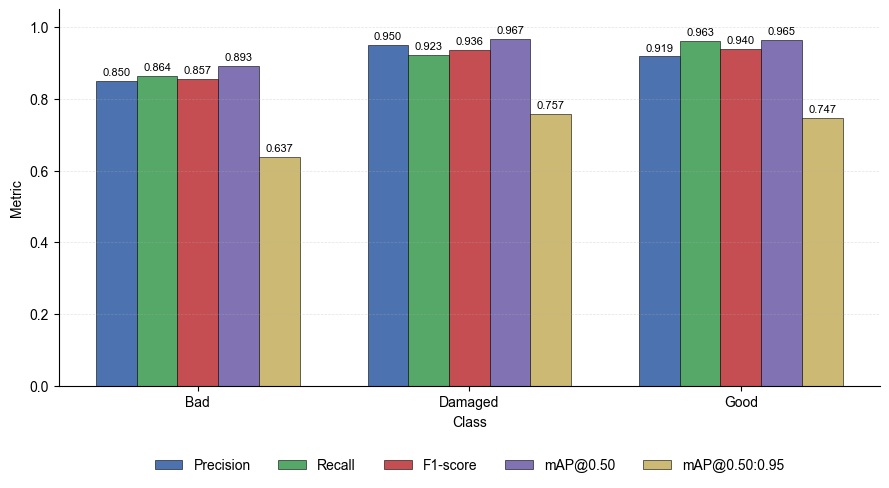

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Dados
# ----------------------------
plot_df = df[df["Class"] != "Overall"].copy()

classes = plot_df["Class"]

metrics = {
    "Precision": plot_df["Precision"],
    "Recall": plot_df["Recall"],
    "F1-score": plot_df["F1-score"],
    "mAP@0.50": plot_df["mAP@0.50"],
    "mAP@0.50:0.95": plot_df["mAP@0.50:0.95"]
}

colors = [
    "#4C72B0",
    "#55A868",
    "#C44E52",
    "#8172B3",
    "#CCB974"
]

# ----------------------------
# Figura
# ----------------------------

plt.rcParams.update({
    "font.family":"Arial",
    "font.size":10
})

fig, ax = plt.subplots(figsize=(9,5))

x = np.arange(len(classes))
width = 0.15

bars = []

for i, (metric, values) in enumerate(metrics.items()):

    offset = (i-2)*width

    b = ax.bar(
        x+offset,
        values,
        width,
        label=metric,
        color=colors[i],
        edgecolor='black',
        linewidth=0.4
    )

    bars.append(b)

# ----------------------------
# Valores
# ----------------------------

for group in bars:

    for bar in group:

        h = bar.get_height()

        ax.text(
            bar.get_x()+bar.get_width()/2,
            h+0.01,
            f"{h:.3f}",
            ha='center',
            va='bottom',
            fontsize=8
        )

# ----------------------------
# Estilo
# ----------------------------

ax.set_ylim(0,1.05)

ax.set_ylabel("Metric")

ax.set_xlabel("Class")

ax.set_xticks(x)
ax.set_xticklabels(classes)

ax.grid(axis="y",
        linestyle="--",
        linewidth=0.5,
        alpha=0.35)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# legenda abaixo

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5,-0.16),
    ncol=5,
    frameon=False
)

plt.tight_layout()

# alta resolução

plt.savefig(
    "Figure_PerformanceMetrics.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_PerformanceMetrics.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Figure_PerformanceMetrics.svg",
    bbox_inches="tight"
)

plt.show()

In [16]:
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Carregar o modelo treinado
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Pasta das imagens de teste
image_dir = "/content/corn-4/test/images"

# Lista de imagens
images = sorted([
    os.path.join(image_dir, img)
    for img in os.listdir(image_dir)
    if img.endswith((".jpg", ".jpeg", ".png"))
])

times = []

print(f"Total de imagens: {len(images)}")

for img in images:

    start = time.perf_counter()

    model.predict(
        source=img,
        conf=0.25,
        verbose=False
    )

    end = time.perf_counter()

    inference_time = (end - start)*1000   # ms

    times.append(inference_time)

# DataFrame
df = pd.DataFrame({
    "Image": [os.path.basename(i) for i in images],
    "Inference_Time_ms": times
})

df.to_csv("inference_times.csv", index=False)

print(df.head())

Total de imagens: 56
                                               Image  Inference_Time_ms
0  20220327_0107_jpg.rf.0902cfd33ed9e744116cdf33e...         152.032419
1  20220327_0117_jpg.rf.281c3bd1dd2f9e49e3aeeb690...          21.201326
2  20220327_0120_jpg.rf.8ba83bceba387d8fa3b0b68d1...          20.823301
3  20220327_0124_jpg.rf.7d1f60f9469cbb649f032f7ca...          21.408486
4  20220327_0128_jpg.rf.a0e80284d59a4e1f0d1d197b9...          21.814140


In [17]:
print("\nInference Time Statistics\n")

print(f"Mean      : {df['Inference_Time_ms'].mean():.2f} ms")
print(f"Median    : {df['Inference_Time_ms'].median():.2f} ms")
print(f"Std Dev   : {df['Inference_Time_ms'].std():.2f} ms")
print(f"Minimum   : {df['Inference_Time_ms'].min():.2f} ms")
print(f"Maximum   : {df['Inference_Time_ms'].max():.2f} ms")

fps = 1000/df['Inference_Time_ms'].mean()

print(f"Average FPS: {fps:.2f}")


Inference Time Statistics

Mean      : 17.23 ms
Median    : 13.76 ms
Std Dev   : 18.52 ms
Minimum   : 13.06 ms
Maximum   : 152.03 ms
Average FPS: 58.03


In [18]:
# Warm-up
model.predict(source=images[0], verbose=False)

times = []

for img in images:
    start = time.perf_counter()
    model.predict(source=img, verbose=False)
    end = time.perf_counter()
    times.append((end - start) * 1000)

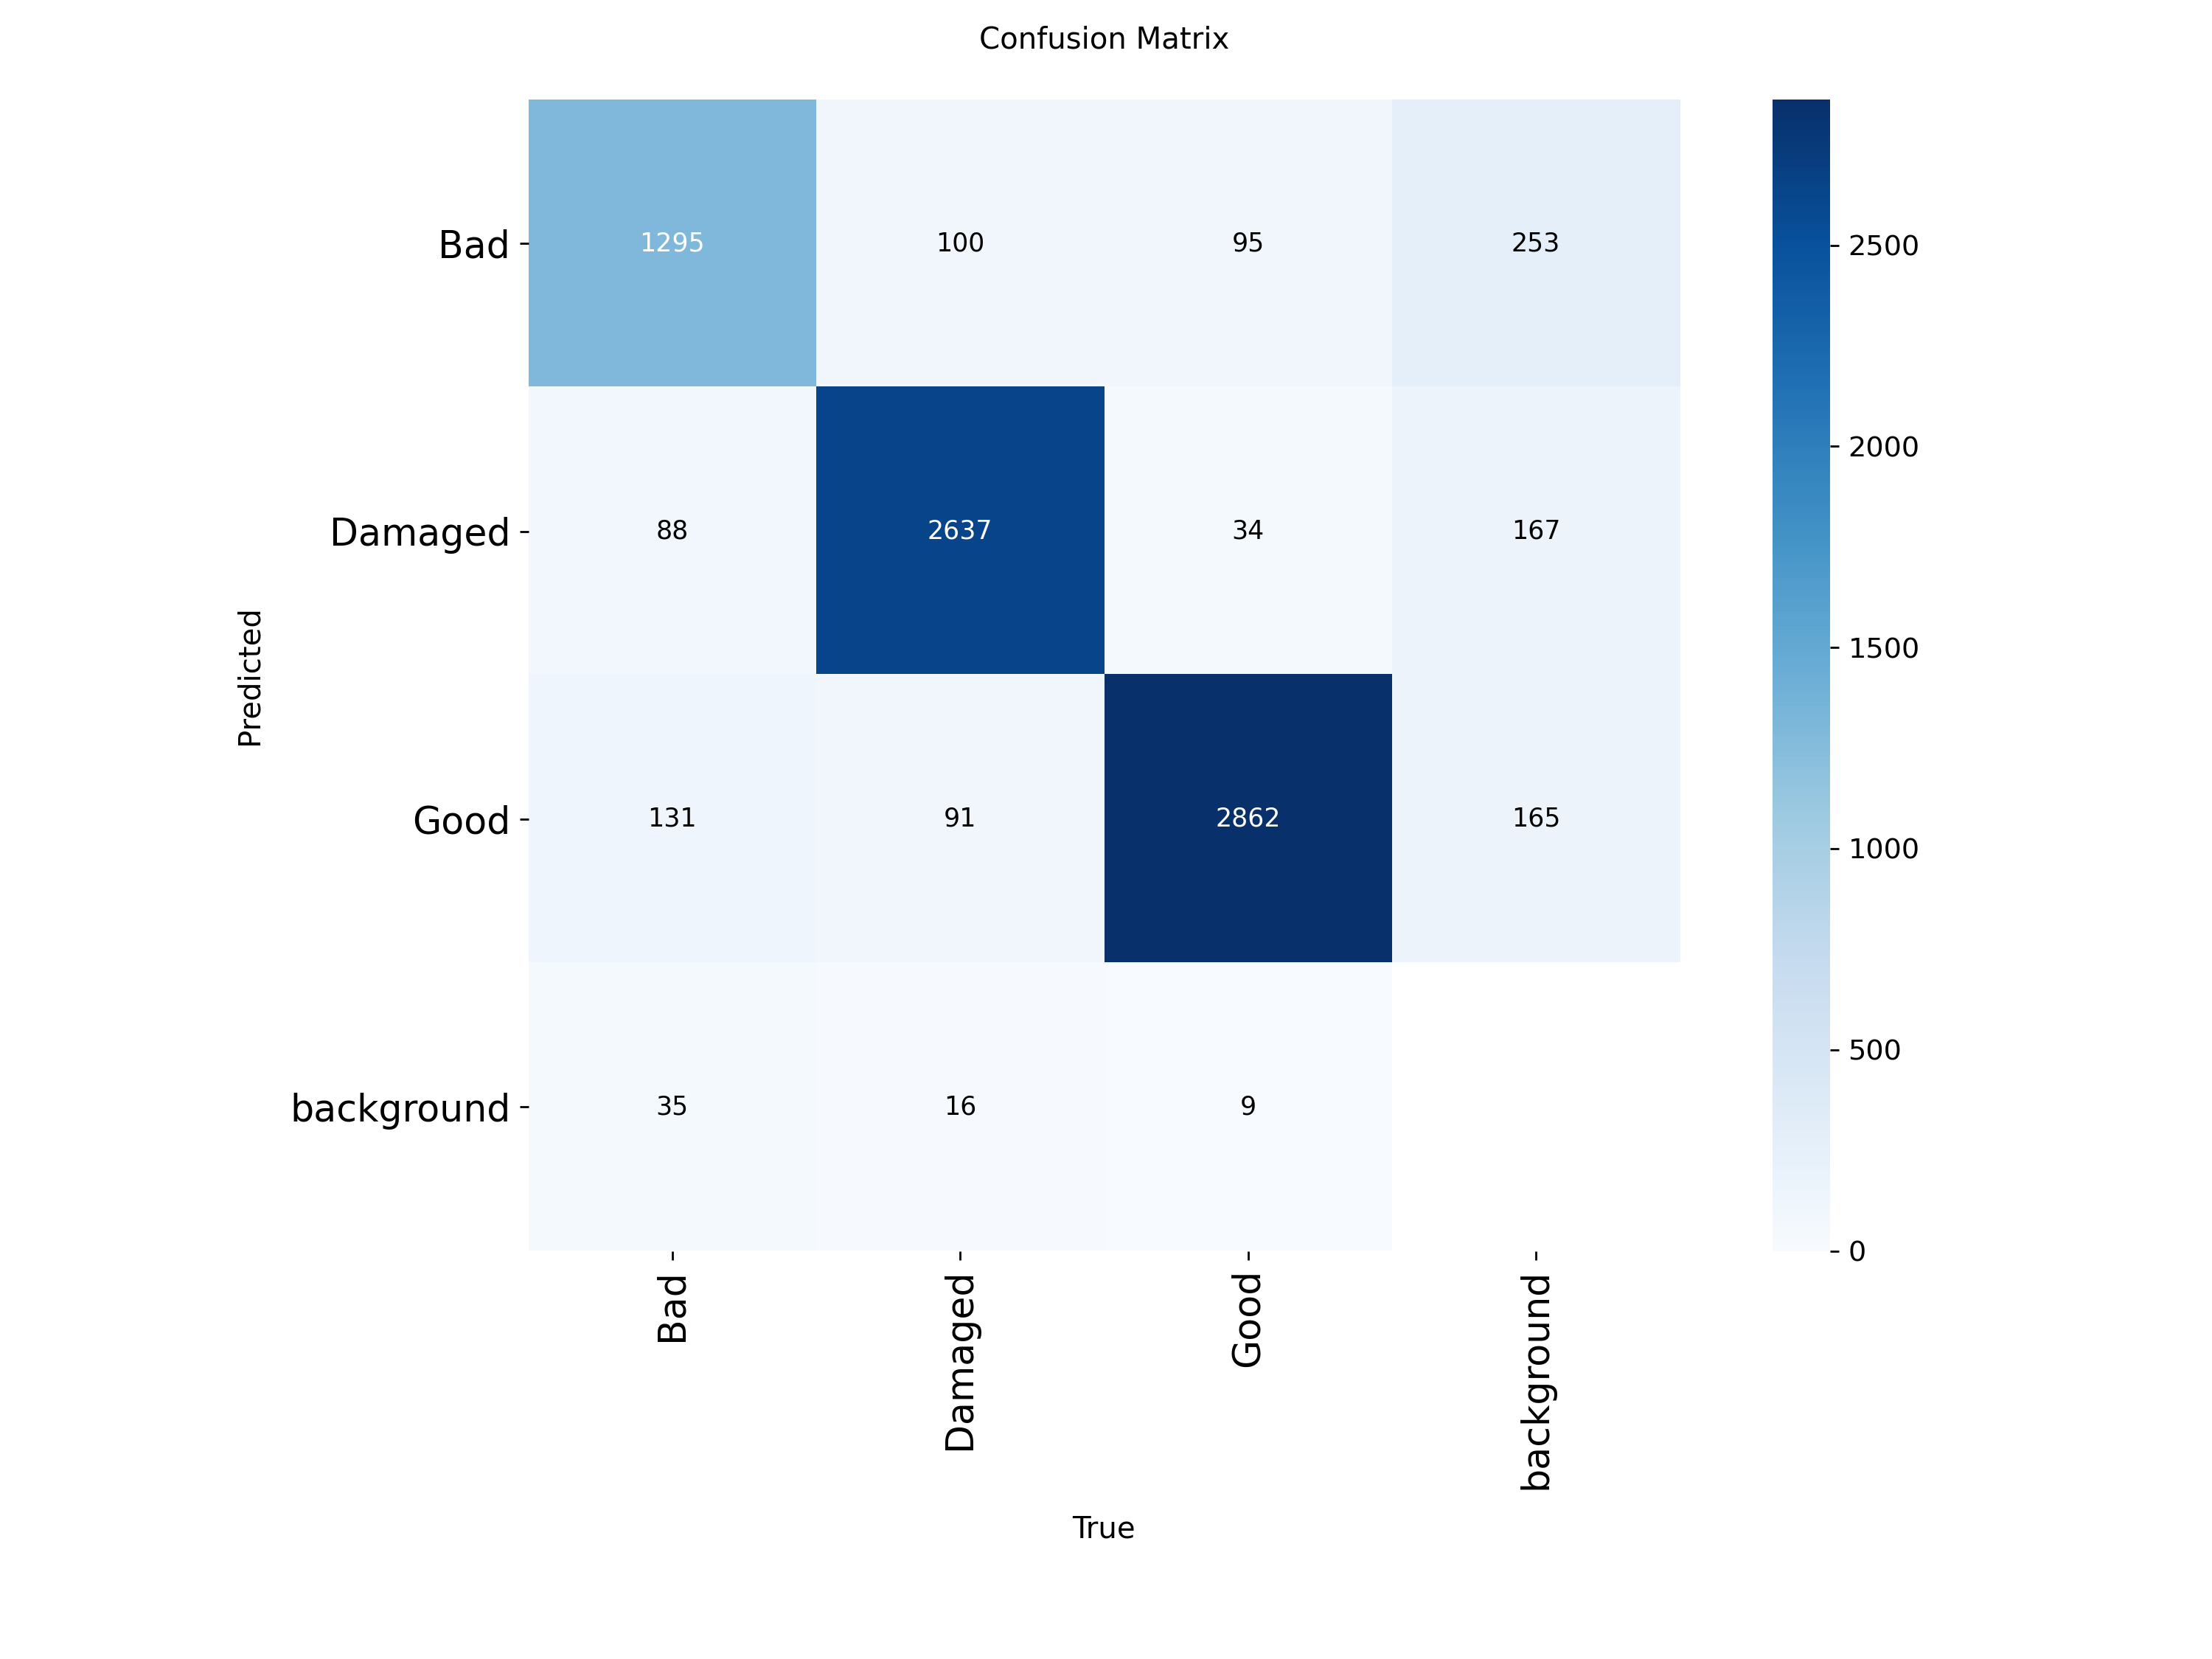

In [19]:
from IPython.display import Image, display

display(Image(filename='runs/detect/train/confusion_matrix.png', width=800))

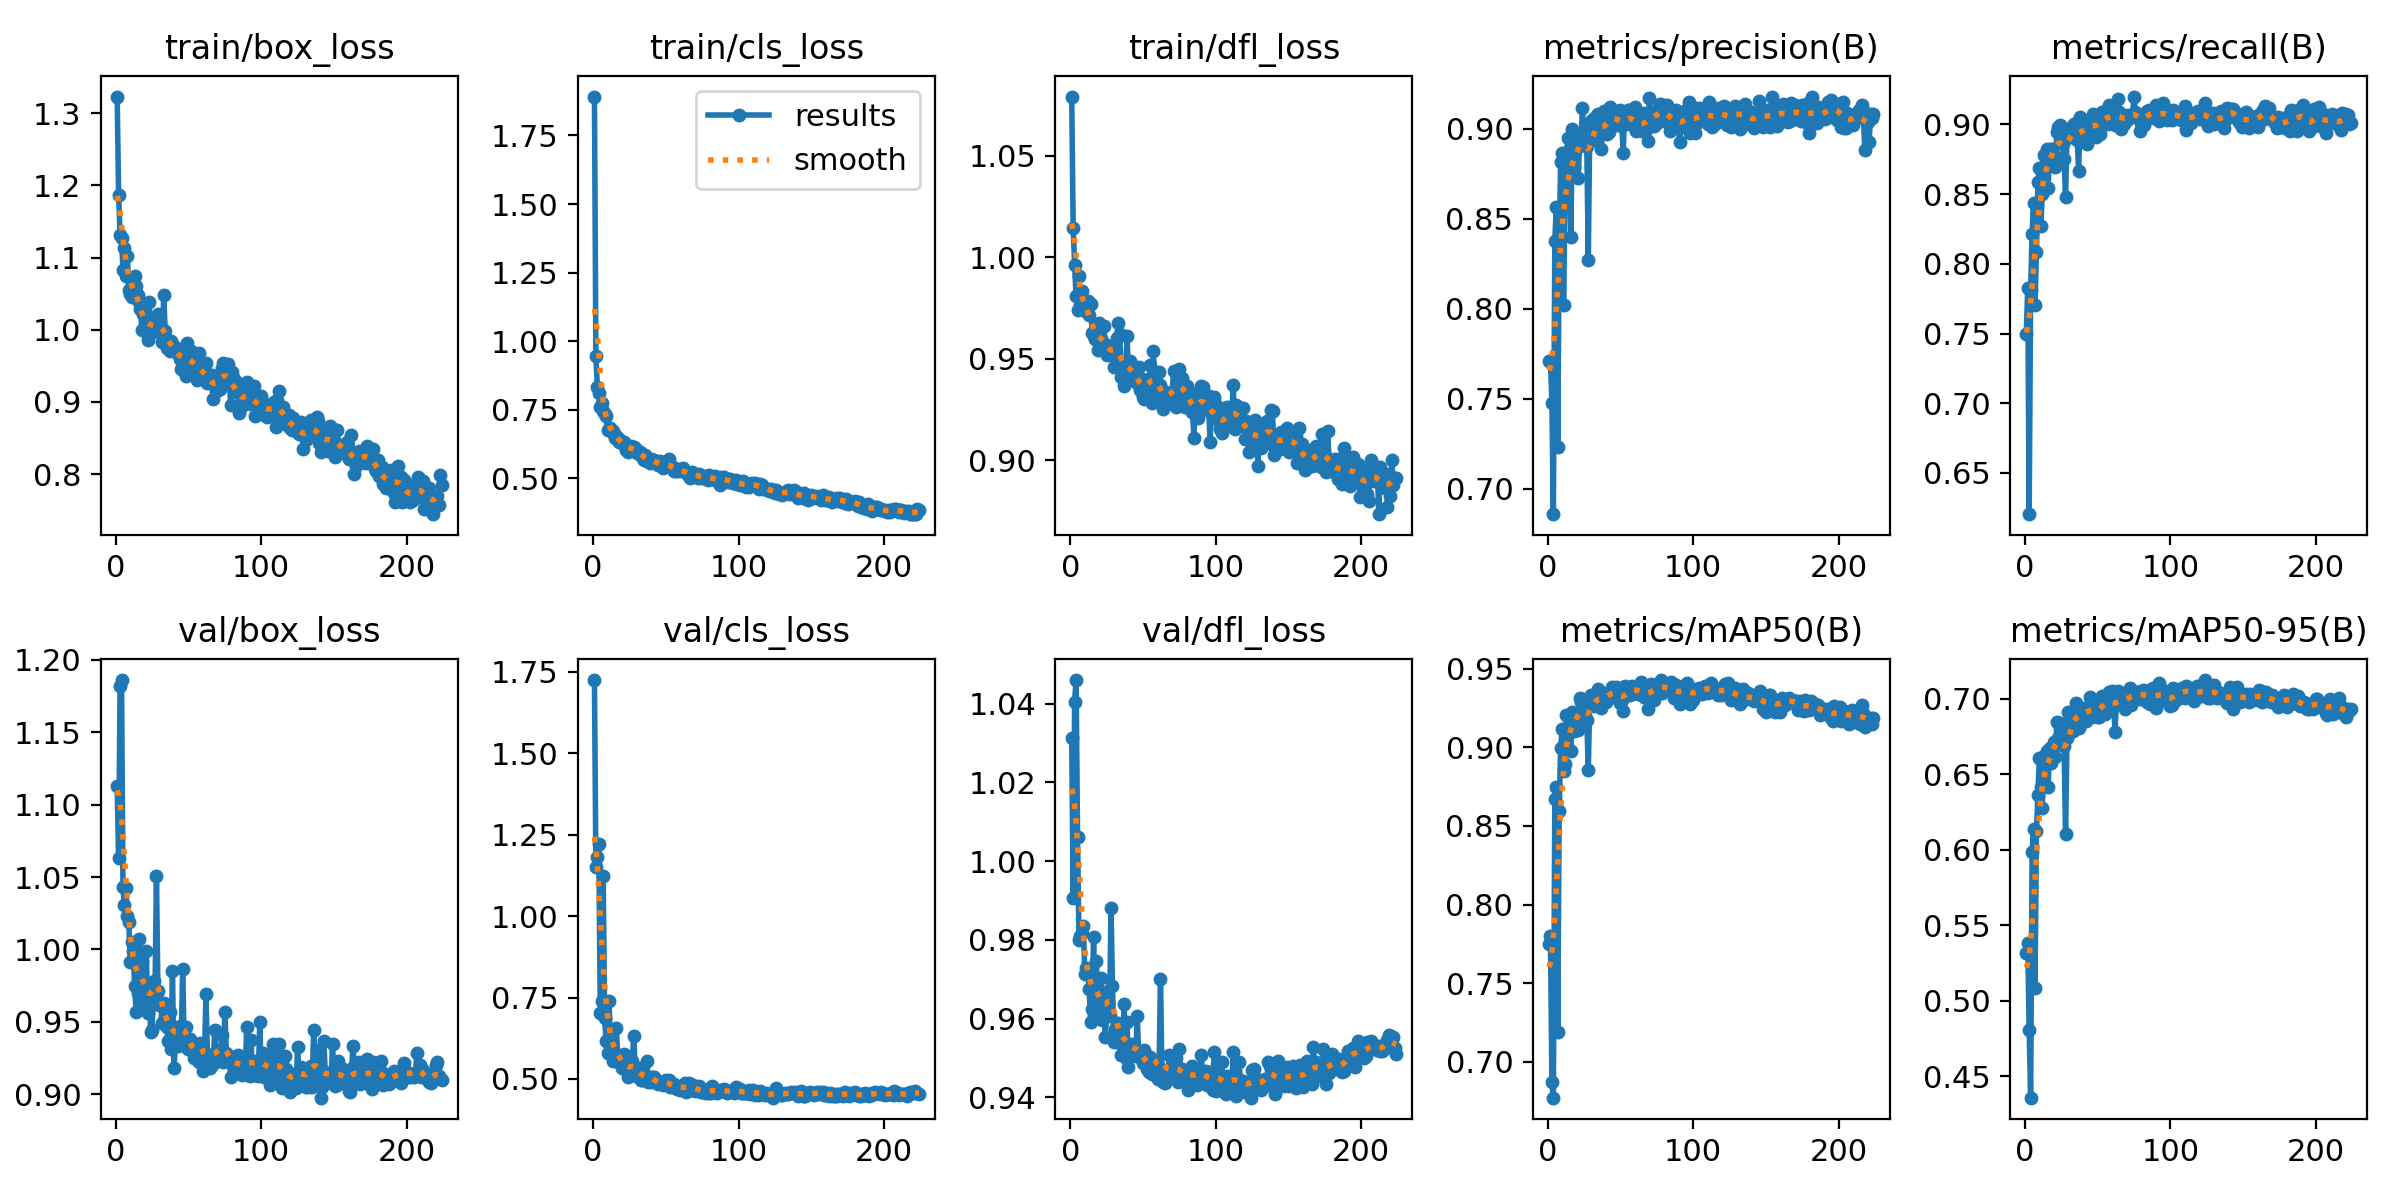

In [20]:
from IPython.display import Image, display

Image(filename='runs/detect/train/results.png', width=800)

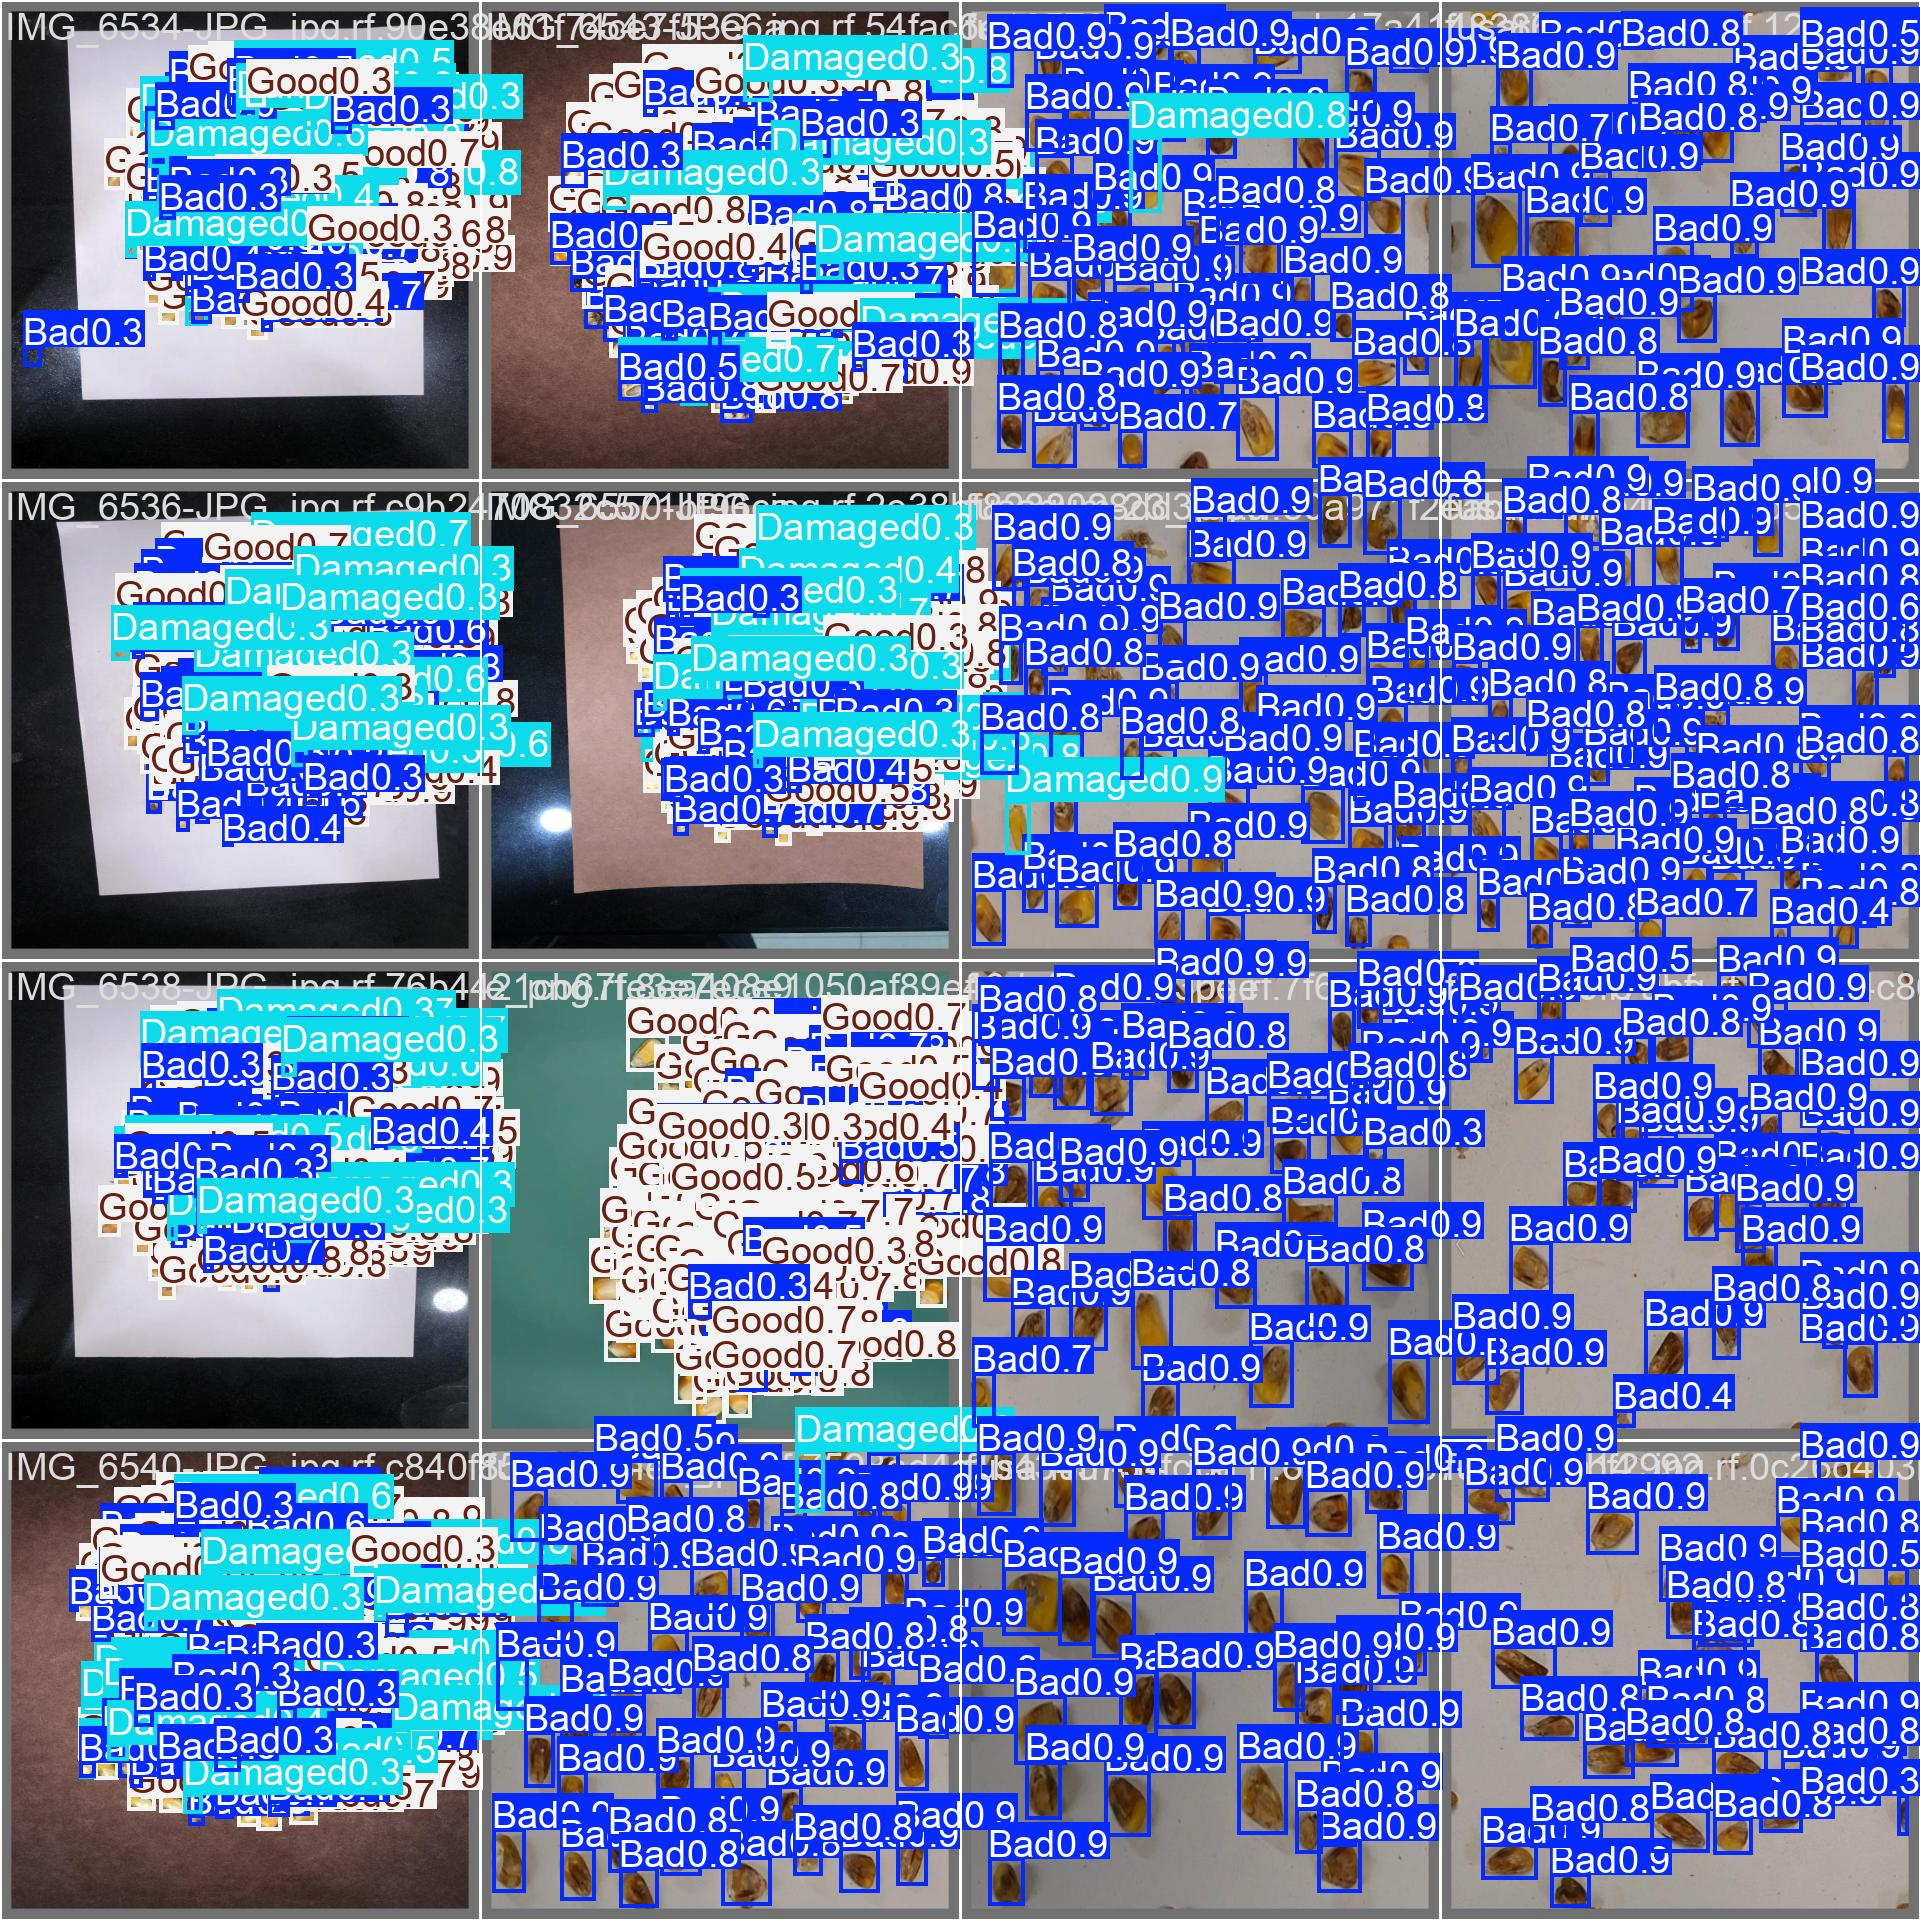

In [21]:
from IPython.display import Image, display

Image(filename='runs/detect/train/val_batch0_pred.jpg', width=800)
Image(filename='runs/detect/train/val_batch1_pred.jpg', width=800)
Image(filename='runs/detect/train/val_batch2_pred.jpg', width=800)

In [ ]:
from ultralytics import YOLO

model = YOLO('runs/detect/train/weights/best.pt')

metrics = model.val(data=f"{dataset.location}/data.yaml")

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Loss:", metrics.box.mp)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1148.0±387.2 MB/s, size: 27.7 KB)
val: Scanning /content/corn-4/valid/labels.cache... 111 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 111/111 46.6Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1380, len(boxes) = 7393. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.4s/it 9.8s
                   all        111       7393      0.906      0.917      0.941      0.714
                   Bad         51       1549       0.85      0.864      0.893      0.637
               Damaged         92       284

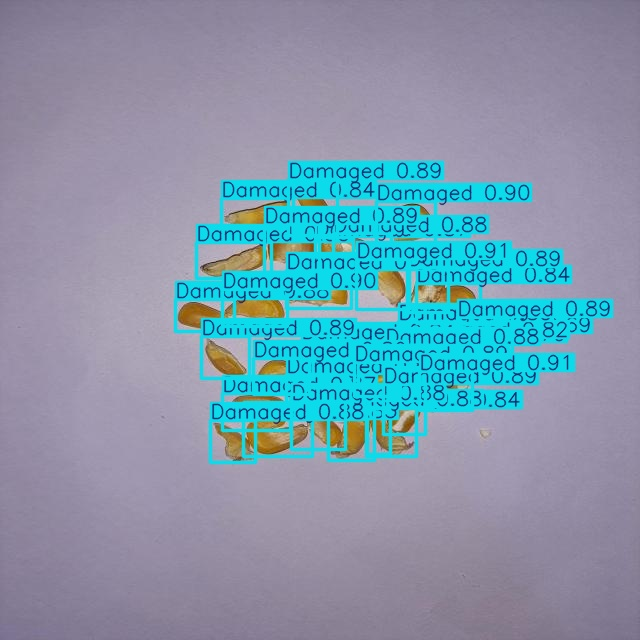

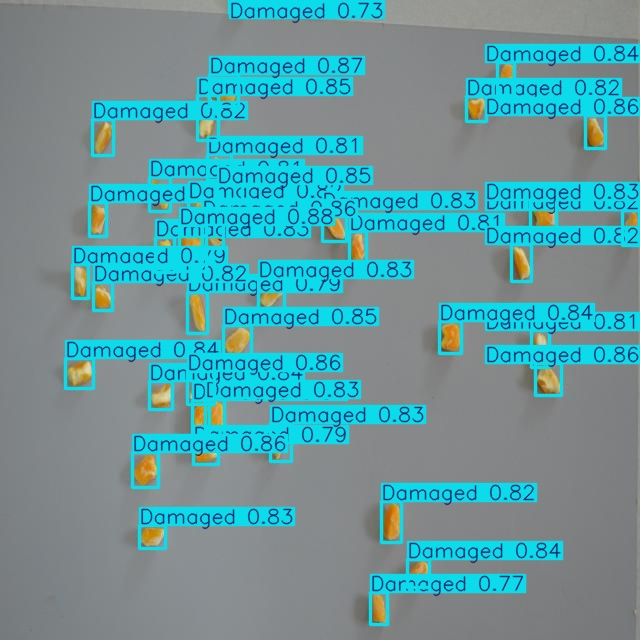

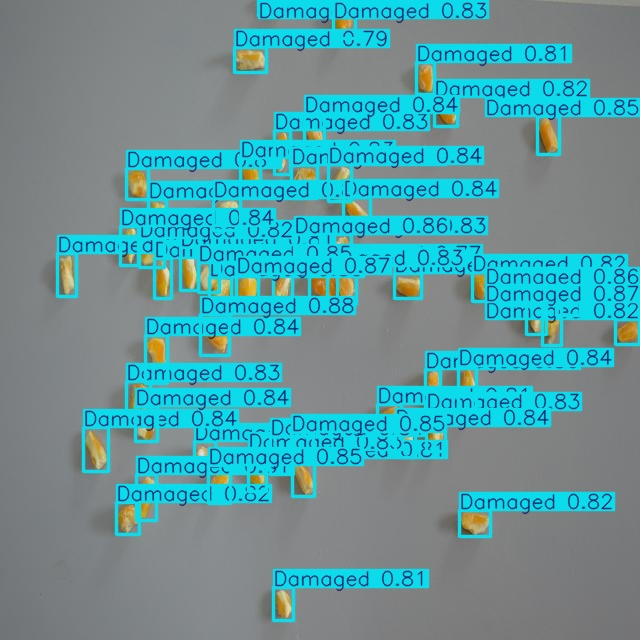

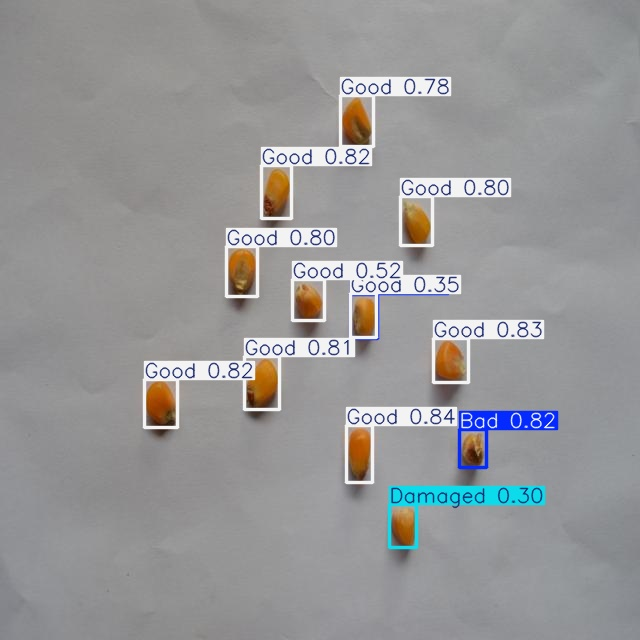

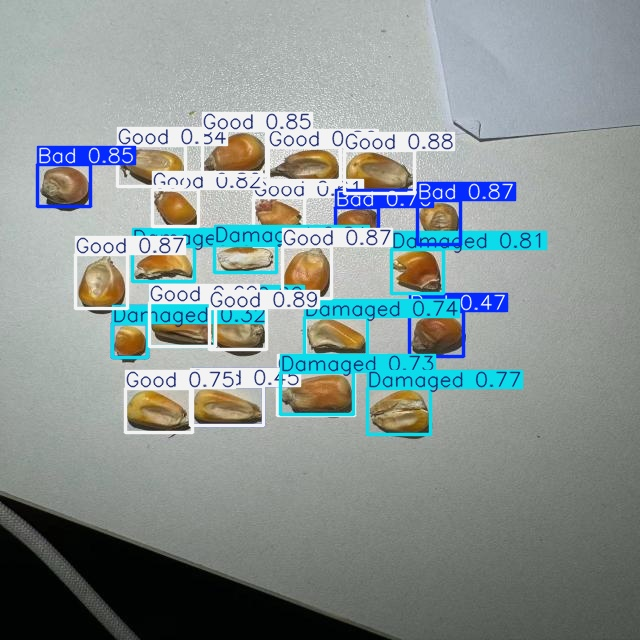

In [22]:
from IPython.display import Image, display
import os

pred_dir = 'runs/detect/predict'

for img in os.listdir(pred_dir)[:5]:
    display(Image(filename=f"{pred_dir}/{img}", width=600))

Objetos detectados por imagem:
[54, 50, 41, 32, 37, 38, 44, 54, 42, 50, 46, 54, 59, 14, 60, 39, 40, 36, 32, 5, 4, 5, 5, 5, 5, 6, 28, 33, 191, 188, 188, 34, 34, 28, 13, 34, 123, 124, 194, 61, 62, 189, 184, 37, 18, 42, 42, 48, 46, 45, 26, 26, 28, 26, 30, 115]
Média: 55.25
Mínimo: 4
Máximo: 194
Desvio padrão: 52.51


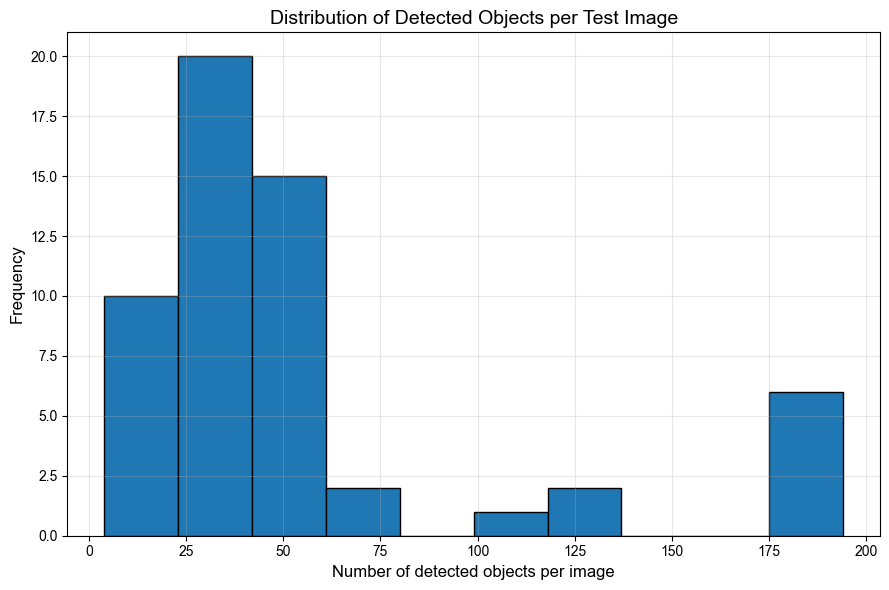

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# results é o retorno do model.predict()
# Exemplo:
# results = model.predict(...)

# Número de objetos detectados em cada imagem
num_objects = [len(r.boxes) for r in results]

print("Objetos detectados por imagem:")
print(num_objects)

print(f"Média: {np.mean(num_objects):.2f}")
print(f"Mínimo: {np.min(num_objects)}")
print(f"Máximo: {np.max(num_objects)}")
print(f"Desvio padrão: {np.std(num_objects):.2f}")

# Histograma
plt.figure(figsize=(9,6))

plt.hist(num_objects,
         bins=10,
         edgecolor='black')

plt.xlabel("Number of detected objects per image", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Detected Objects per Test Image", fontsize=14)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("histogram_detected_objects.png", dpi=300)

plt.show()